In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (confusion_matrix, f1_score, classification_report,
                             ConfusionMatrixDisplay)

print("All libraries loaded!")

All libraries loaded!


In [2]:
from google.colab import files
uploaded = files.upload()

import os
print(os.listdir('/content'))

Saving 4bb936ec-189a-4a96-8818-e19ac0d167e5.csv to 4bb936ec-189a-4a96-8818-e19ac0d167e5.csv
['.config', '4bb936ec-189a-4a96-8818-e19ac0d167e5.csv', 'sample_data']


In [3]:
df = pd.read_csv('/content/4bb936ec-189a-4a96-8818-e19ac0d167e5.csv')
print("Shape:", df.shape)
print(df.head())
print(df.isnull().sum())

# Drop missing values
df = df.dropna()
print("Shape after cleaning:", df.shape)

Shape: (129880, 22)
  satisfaction   Customer Type  Age   Type of Travel     Class  \
0    satisfied  Loyal Customer   65  Personal Travel       Eco   
1    satisfied  Loyal Customer   47  Personal Travel  Business   
2    satisfied  Loyal Customer   15  Personal Travel       Eco   
3    satisfied  Loyal Customer   60  Personal Travel       Eco   
4    satisfied  Loyal Customer   70  Personal Travel       Eco   

   Flight Distance  Seat comfort  Departure/Arrival time convenient  \
0              265             0                                  0   
1             2464             0                                  0   
2             2138             0                                  0   
3              623             0                                  0   
4              354             0                                  0   

   Food and drink  Gate location  ...  Online support  Ease of Online booking  \
0               0              2  ...               2                      

In [4]:
le = LabelEncoder()
df['satisfaction'] = le.fit_transform(df['satisfaction'])
df['Customer Type'] = le.fit_transform(df['Customer Type'])
df['Type of Travel'] = le.fit_transform(df['Type of Travel'])
df['Class'] = le.fit_transform(df['Class'])

print("Encoding complete!")
print(df.head())

Encoding complete!
   satisfaction  Customer Type  Age  Type of Travel  Class  Flight Distance  \
0             1              0   65               1      1              265   
1             1              0   47               1      0             2464   
2             1              0   15               1      1             2138   
3             1              0   60               1      1              623   
4             1              0   70               1      1              354   

   Seat comfort  Departure/Arrival time convenient  Food and drink  \
0             0                                  0               0   
1             0                                  0               0   
2             0                                  0               0   
3             0                                  0               0   
4             0                                  0               0   

   Gate location  ...  Online support  Ease of Online booking  \
0              2  ..

In [5]:
X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (103589, 21)
Testing set size: (25898, 21)


In [6]:
# GridSearchCV to find best hyperparameters
param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt, param_grid, cv=5,
                           scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best F1 score:", round(grid_search.best_score_, 3))

Best parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best F1 score: 0.943


In [7]:
# Train with best parameters
best_model = DecisionTreeClassifier(
    **grid_search.best_params_,
    random_state=42
)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("Model trained successfully!")
print()
print("F1-Score:", round(f1_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred,
      target_names=['Dissatisfied', 'Satisfied']))

Model trained successfully!

F1-Score: 0.946

              precision    recall  f1-score   support

Dissatisfied       0.93      0.95      0.94     11821
   Satisfied       0.96      0.94      0.95     14077

    accuracy                           0.94     25898
   macro avg       0.94      0.94      0.94     25898
weighted avg       0.94      0.94      0.94     25898



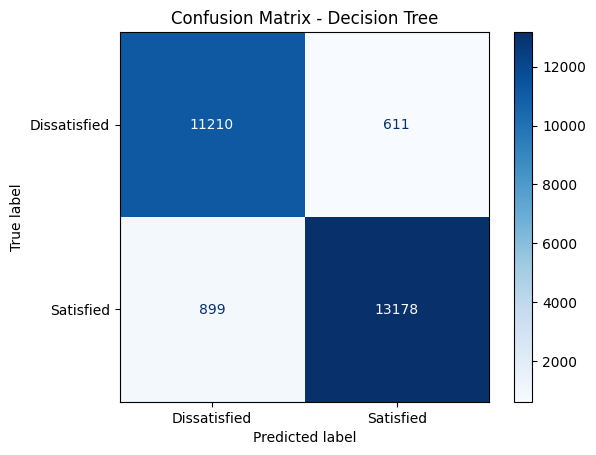

Confusion Matrix:
[[11210   611]
 [  899 13178]]


In [8]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Dissatisfied', 'Satisfied'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

print("Confusion Matrix:")
print(cm)

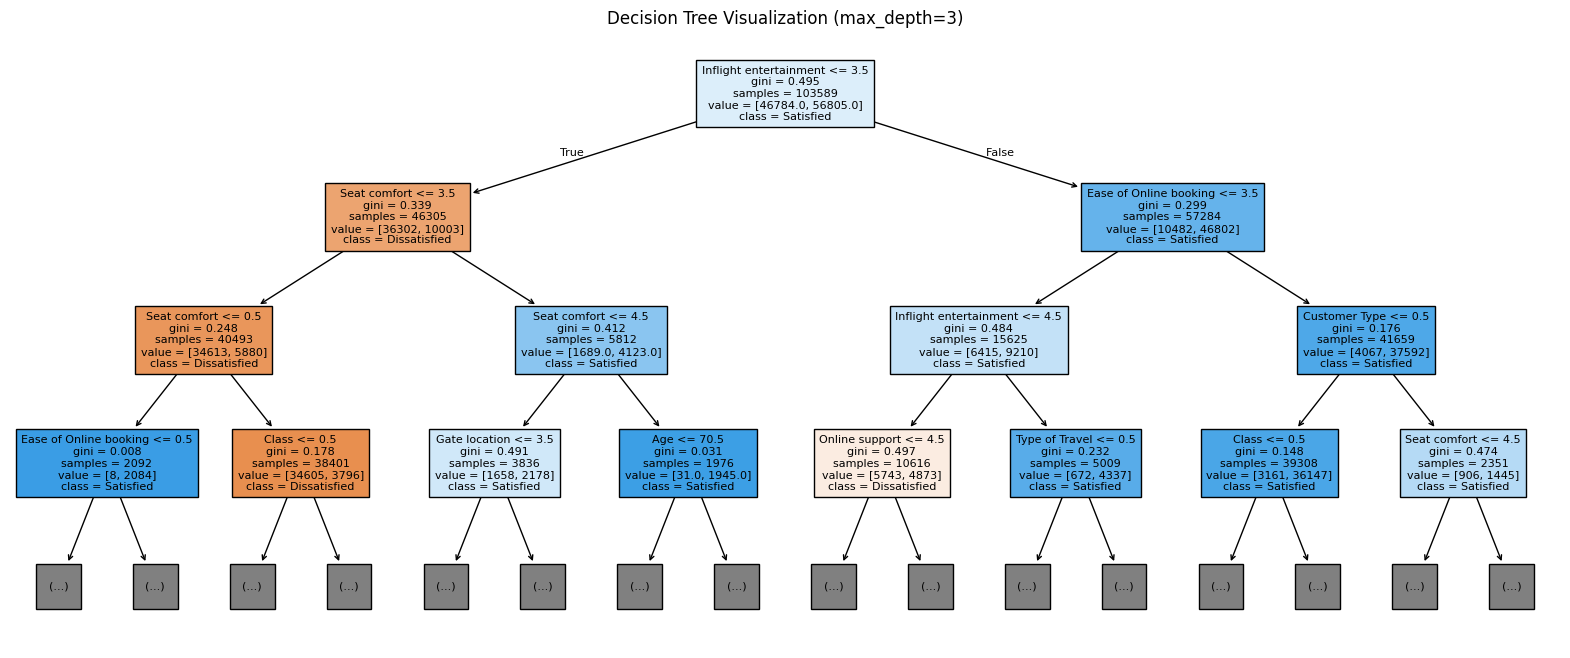

In [9]:
plt.figure(figsize=(20, 8))
plot_tree(best_model,
          feature_names=X.columns,
          class_names=['Dissatisfied', 'Satisfied'],
          filled=True,
          max_depth=3,
          fontsize=8)
plt.title('Decision Tree Visualization (max_depth=3)')
plt.show()

Top 10 Feature Importances:
                              Feature  Importance
10             Inflight entertainment    0.439881
5                        Seat comfort    0.197613
12             Ease of Online booking    0.071280
0                       Customer Type    0.046885
8                       Gate location    0.025704
3                               Class    0.024292
2                      Type of Travel    0.023939
6   Departure/Arrival time convenient    0.020930
11                     Online support    0.016759
16                    Checkin service    0.016449


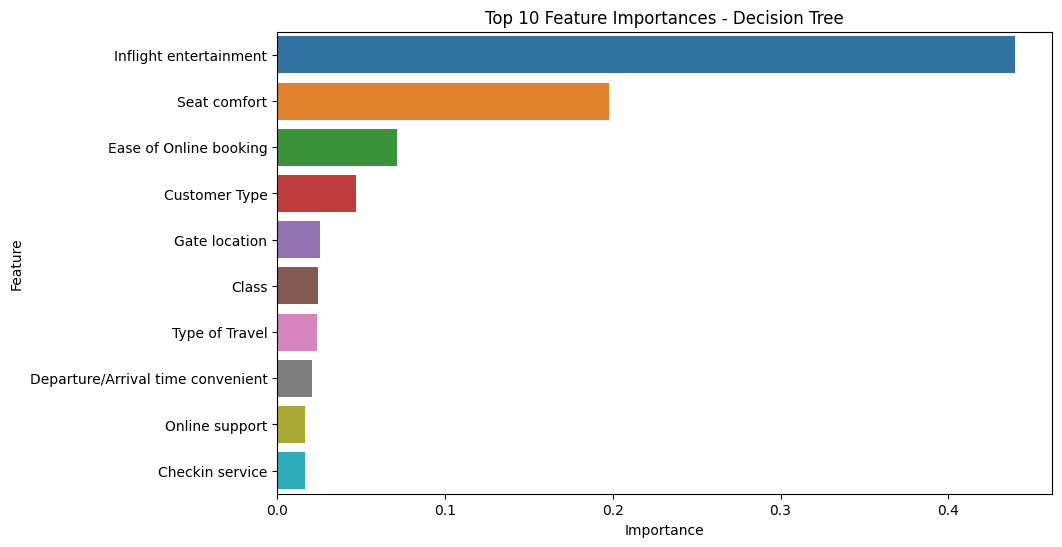

In [10]:
# Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Feature Importances:")
print(importance_df.head(10))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature',
            data=importance_df.head(10),
            hue='Feature', legend=False)
plt.title('Top 10 Feature Importances - Decision Tree')
plt.show()

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Logistic Regression for comparison
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print("=" * 55)
print("MODEL COMPARISON")
print("=" * 55)
print()
print(f"Decision Tree F1-Score:      {f1_score(y_test, y_pred):.3f}")
print(f"Logistic Regression F1-Score:{f1_score(y_test, y_pred_lr):.3f}")
print()
print("INTERPRETABILITY:")
print("Decision Tree   — HIGH: visual pathways, easy to audit")
print("Logistic Regression — MEDIUM: coefficients need expertise")
print()
print("NON-LINEAR RELATIONSHIPS:")
print("Decision Tree   — Handles non-linear relationships well")
print("Logistic Regression — Assumes linear decision boundary")
print()
print("BUSINESS ACTIONABILITY:")
print("Decision Tree   — Easy to explain to airline management")
print("Logistic Regression — Better for probability estimates")
print("=" * 55)

MODEL COMPARISON

Decision Tree F1-Score:      0.946
Logistic Regression F1-Score:0.842

INTERPRETABILITY:
Decision Tree   — HIGH: visual pathways, easy to audit
Logistic Regression — MEDIUM: coefficients need expertise

NON-LINEAR RELATIONSHIPS:
Decision Tree   — Handles non-linear relationships well
Logistic Regression — Assumes linear decision boundary

BUSINESS ACTIONABILITY:
Decision Tree   — Easy to explain to airline management
Logistic Regression — Better for probability estimates


In [12]:
print("=" * 60)
print("AIRLINE SATISFACTION - DECISION TREE FINDINGS")
print("=" * 60)
print()
print(f"BEST HYPERPARAMETERS: {grid_search.best_params_}")
print()
print("MODEL PERFORMANCE:")
print(f"F1-Score: {round(f1_score(y_test, y_pred), 3)}")
print()
print("TOP 5 DRIVERS OF SATISFACTION:")
for i, row in importance_df.head(5).iterrows():
    print(f"  {row['Feature']:35} {row['Importance']:.3f}")
print()
print("RECOMMENDATIONS FOR AIRLINE MANAGEMENT:")
print("1. Prioritize top features to improve satisfaction")
print("2. Use decision tree pathways for staff training")
print("3. Focus investment on highest importance features")
print("4. Monitor satisfaction scores quarterly")
print("5. Deploy model for real-time passenger screening")
print("=" * 60)

AIRLINE SATISFACTION - DECISION TREE FINDINGS

BEST HYPERPARAMETERS: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10}

MODEL PERFORMANCE:
F1-Score: 0.946

TOP 5 DRIVERS OF SATISFACTION:
  Inflight entertainment              0.440
  Seat comfort                        0.198
  Ease of Online booking              0.071
  Customer Type                       0.047
  Gate location                       0.026

RECOMMENDATIONS FOR AIRLINE MANAGEMENT:
1. Prioritize top features to improve satisfaction
2. Use decision tree pathways for staff training
3. Focus investment on highest importance features
4. Monitor satisfaction scores quarterly
5. Deploy model for real-time passenger screening
